In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../Data/Global_Supply_Chain_2024to2025.csv")
df["Date"] = pd.to_datetime(df["Date"])

df_clean = df.copy()

In [8]:
df_clean["Lead_Time_Days"].describe()

count    5000.000000
mean       19.355386
std        31.405143
min         0.500000
25%         2.110000
50%         8.245000
75%        21.207500
max       236.390000
Name: Lead_Time_Days, dtype: float64

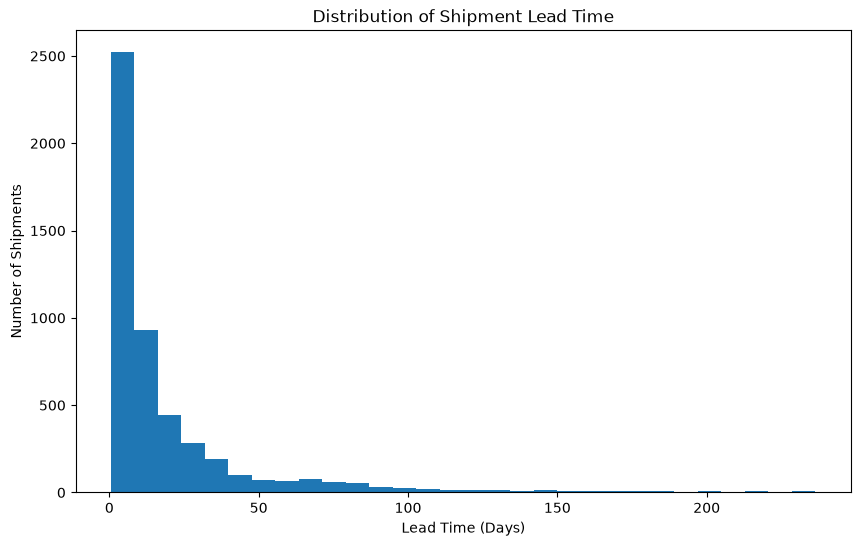

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["Lead_Time_Days"], bins=30)

plt.title("Distribution of Shipment Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Shipments")

plt.show()

In [11]:
df_clean.groupby("Transport_Mode")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Transport_Mode,,,,,
Air,1320,1.64,0.93,0.5,8.63
Rail,1185,19.95,11.54,0.5,117.76
Road,1214,16.45,9.30,0.5,102.30
Sea,1281,39.80,21.79,0.5,236.39


In [13]:
df_clean.groupby("Transport_Mode")["Distance_km"].agg(["count", "mean", "median", "max"]).round(2)

,count,mean,median,max
Transport_Mode,,,,
Air,1320,7764.01,7975.64,14993.59
Rail,1185,7810.04,7903.42,14995.91
Road,1214,7593.07,7545.28,14991.50
Sea,1281,7649.46,7533.87,14970.04


In [14]:
df_clean[["Distance_km", "Lead_Time_Days"]].corr().round(2)

,Distance_km,Lead_Time_Days
Distance_km,1.00,0.34
Lead_Time_Days,0.34,1.00


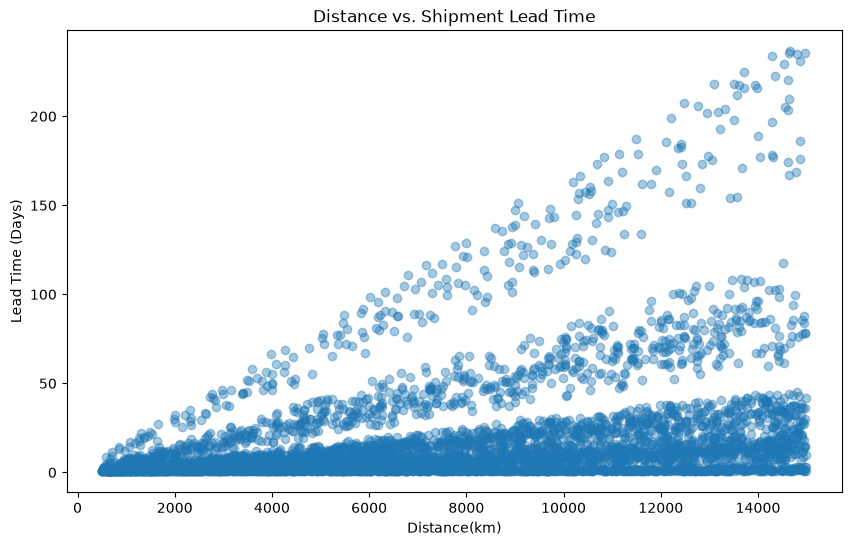

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["Distance_km"], 
    df_clean["Lead_Time_Days"], 
    alpha=0.4
)

plt.title("Distance vs. Shipment Lead Time")
plt.xlabel("Distance(km)")
plt.ylabel("Lead Time (Days)")
plt.show()

In [16]:
df_clean[[
    "Carrier_Reliability_Score", "Lead_Time_Days"
]].corr().round(2)

,Carrier_Reliability_Score,Lead_Time_Days
Carrier_Reliability_Score,1.00,-0.01
Lead_Time_Days,-0.01,1.00


In [18]:
df_clean.groupby("Transport_Mode")["Disruption_Occurred"].agg(["count", "mean"]).round(3)

,count,mean
Transport_Mode,,
Air,1320,0.617
Rail,1185,0.612
Road,1214,0.610
Sea,1281,0.610


In [20]:
df_clean.groupby("Weather_Condition")["Disruption_Occurred"].agg(
    ["count", "mean"]
).round(3)

,count,mean
Weather_Condition,,
Clear,995,0.370
Fog,1036,0.481
Hurricane,990,1.000
Rain,977,0.420
Storm,1002,0.795


In [22]:
pd.crosstab(
    df_clean["Transport_Mode"], 
    df_clean["Weather_Condition"], 
    values=df_clean["Disruption_Occurred"], 
    aggfunc="mean"
).round(3)

Weather_Condition,Clear,Fog,Hurricane,Rain,Storm
Transport_Mode,,,,,
Air,0.350,0.500,1.0,0.444,0.789
Rail,0.384,0.457,1.0,0.387,0.821
Road,0.377,0.484,1.0,0.423,0.774
Sea,0.371,0.479,1.0,0.422,0.798


In [23]:
df_clean["Geo_Risk_Level"] = pd.cut(
    df_clean["Geopolitical_Risk_Score"], 
    bins=[-0.01, 3.33, 6.67, 10], 
    labels=["Low", "Medium", "High"]
)

df_clean.groupby("Geo_Risk_Level", observed=True)["Disruption_Occurred"].agg((
    ["count", "mean"]
)).round(3)

,count,mean
Geo_Risk_Level,,
Low,1596,0.472
Medium,1677,0.624
High,1727,0.731


In [25]:
df_clean.groupby("Disruption_Occurred")["Carrier_Reliability_Score"].agg([
    "count", "mean", "median", "min", "max"
]).round(3)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,0.769,0.781,0.5,1.0
1,3063,0.745,0.741,0.5,1.0


In [26]:
df_clean.groupby("Disruption_Occurred")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,8.89,6.24,0.5,85.02
1,3063,25.98,10.69,0.5,236.39


In [27]:
df_clean.columns.tolist()

['Shipment_ID',
 'Date',
 'Origin_Port',
 'Destination_Port',
 'Transport_Mode',
 'Product_Category',
 'Distance_km',
 'Weight_MT',
 'Fuel_Price_Index',
 'Geopolitical_Risk_Score',
 'Weather_Condition',
 'Carrier_Reliability_Score',
 'Lead_Time_Days',
 'Disruption_Occurred',
 'Geo_Risk_Level']

In [28]:
df_clean = df_clean.drop(columns=["Geo_Risk_Level"])

df_clean.columns.tolist()

['Shipment_ID',
 'Date',
 'Origin_Port',
 'Destination_Port',
 'Transport_Mode',
 'Product_Category',
 'Distance_km',
 'Weight_MT',
 'Fuel_Price_Index',
 'Geopolitical_Risk_Score',
 'Weather_Condition',
 'Carrier_Reliability_Score',
 'Lead_Time_Days',
 'Disruption_Occurred']

In [29]:
df_clean.groupby("Product_Category")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Product_Category,,,,,
Automotive,959,18.98,7.72,0.5,233.78
Electronics,1016,17.76,8.00,0.5,234.84
Perishables,1009,20.13,8.17,0.5,236.39
Pharmaceuticals,1006,19.80,8.86,0.5,220.25
Textiles,1010,20.10,8.35,0.5,235.41


In [30]:
df_clean.groupby("Product_Category")["Disruption_Occurred"].agg(
    ["count", "mean"]
).round(3)

,count,mean
Product_Category,,
Automotive,959,0.605
Electronics,1016,0.595
Perishables,1009,0.603
Pharmaceuticals,1006,0.611
Textiles,1010,0.649


In [31]:
df_clean[["Fuel_Price_Index", "Lead_Time_Days"]].corr().round(2)

,Fuel_Price_Index,Lead_Time_Days
Fuel_Price_Index,1.00,-0.01
Lead_Time_Days,-0.01,1.00


In [32]:
df_clean.groupby("Disruption_Occurred")["Fuel_Price_Index"].agg(
    ["count", "mean", "median", "min", "max"]
).round(3)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,2.850,2.84,1.21,4.5
1,3063,2.857,2.83,1.20,4.5


In [33]:
df_clean[["Weight_MT", "Lead_Time_Days"]].corr().round(2)

,Weight_MT,Lead_Time_Days
Weight_MT,1.00,-0.01
Lead_Time_Days,-0.01,1.00


In [34]:
df_clean.groupby("Disruption_Occurred")["Weight_MT"].agg([
    "count", "mean", "median", "min", "max"
]).round(2)

,count,mean,median,min,max
Disruption_Occurred,,,,,
0,1937,243.97,240.25,1.12,499.60
1,3063,247.70,245.40,1.03,499.75


In [37]:
df_clean.groupby("Origin_Port")["Disruption_Occurred"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False).round(3)

,count,mean
Origin_Port,,
Hamburg,597,0.625
Shanghai,644,0.624
Singapore,599,0.623
Antwerp,635,0.614
Dubai,610,0.608
Los Angeles,602,0.603
Busan,667,0.603
Rotterdam,646,0.602


In [38]:
df_clean.groupby("Destination_Port")["Disruption_Occurred"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False).round(3)

,count,mean
Destination_Port,,
Singapore,528,0.633
Marseille,583,0.623
Busan,570,0.621
Shanghai,561,0.619
Antwerp,552,0.614
Hamburg,536,0.610
Rotterdam,574,0.606
Los Angeles,537,0.598
Dubai,559,0.590


In [40]:
monthly_disruption =  (
    df_clean.set_index("Date")
    .resample("ME")["Disruption_Occurred"].agg(["count", "mean"])
)

monthly_disruption.round(3)


,count,mean
Date,,
2024-01-31,173,0.636
2024-02-29,195,0.564
2024-03-31,220,0.568
2024-04-30,229,0.624
2024-05-31,211,0.626
2024-06-30,208,0.678
2024-07-31,174,0.575
2024-08-31,199,0.658
2024-09-30,210,0.614


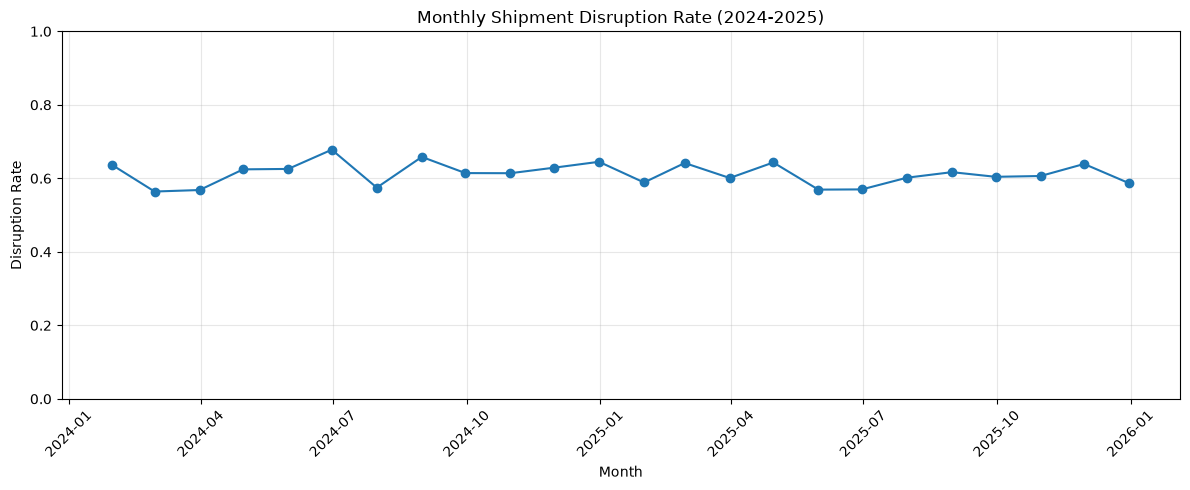

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_disruption.index,
    monthly_disruption["mean"], 
    marker="o"
)

plt.title("Monthly Shipment Disruption Rate (2024-2025)")
plt.xlabel("Month")
plt.ylabel("Disruption Rate")
plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
monthly_lead_time = (
    df_clean.set_index("Date")
    .resample("ME")["Lead_Time_Days"]
    .agg(["count", "mean", "median"])
)

monthly_lead_time.round(2)

,count,mean,median
Date,,,
2024-01-31,173,18.51,8.41
2024-02-29,195,18.19,7.58
2024-03-31,220,20.37,9.80
2024-04-30,229,19.71,8.00
2024-05-31,211,18.34,7.95
2024-06-30,208,21.06,8.56
2024-07-31,174,21.82,9.08
2024-08-31,199,17.48,7.09
2024-09-30,210,16.55,8.56


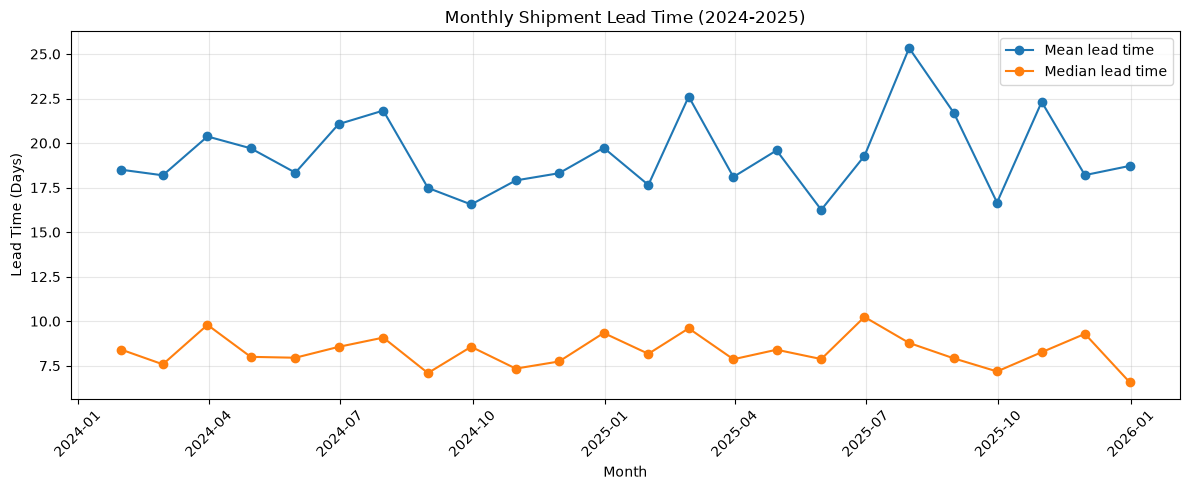

In [43]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_lead_time.index, 
    monthly_lead_time["mean"], 
    marker="o",
    label="Mean lead time"
)

plt.plot(
    monthly_lead_time.index, 
    monthly_lead_time["median"], 
    marker="o", 
    label="Median lead time"

)

plt.title("Monthly Shipment Lead Time (2024-2025)")
plt.xlabel("Month")
plt.ylabel("Lead Time (Days)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
df_clean.groupby("Weather_Condition")["Lead_Time_Days"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Weather_Condition,,,,,
Clear,995,6.70,5.13,0.5,30.09
Fog,1036,9.89,7.00,0.5,45.37
Hurricane,990,53.50,40.03,0.5,236.39
Rain,977,7.74,5.98,0.5,34.53
Storm,1002,19.30,14.72,0.5,87.94


<Figure size 1000x600 with 0 Axes>

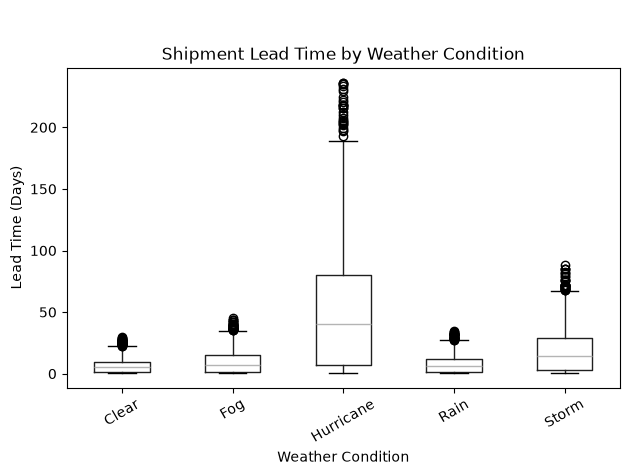

In [46]:
plt.figure(figsize=(10,6))

df_clean.boxplot(
    column="Lead_Time_Days", 
    by="Weather_Condition", 
    grid=False
)

plt.title("Shipment Lead Time by Weather Condition")
plt.suptitle(" ")
plt.xlabel("Weather Condition")
plt.ylabel("Lead Time (Days)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Exploratory Analysis — Key Findings

Shipment Lead Time
Lead times are strongly right-skewed: the median is 8.25 days, while the mean is 19.36 days.
Transport mode is associated with substantial differences in lead-time profiles. Sea shipments have the longest observed lead times, while Air shipments have the shortest.
Distance has a moderate positive correlation with lead time (r = 0.34).
Shipment weight, fuel price index, and carrier reliability score show virtually no linear correlation with lead time in the initial analysis.

Shipment Disruptions
Overall, 61.3% of shipments are recorded as disrupted.
Disruption rates vary substantially by weather condition, with the highest rates under Hurricane and Storm conditions.
Disruption rates increase across the low, medium, and high geopolitical-risk groups.
Disruption rates are relatively similar across transport modes, product categories, and individual origin and destination ports.
Carrier reliability scores are slightly lower on average for disrupted shipments.
Fuel price index and shipment weight show only small descriptive differences between disrupted and non-disrupted shipments.

Time Patterns
Monthly disruption rates fluctuate between 56.4% and 67.8%, without a clear sustained trend across 2024–2025.
Monthly median lead times remain relatively stable, while monthly mean lead times fluctuate more, consistent with the influence of unusually long shipments.

Limitations
These findings describe associations in the dataset and do not establish causation.
The dataset does not provide a promised delivery date, so long lead time should not automatically be interpreted as a delivery delay.
Some observed patterns, particularly the strong relationship between weather and disruption, should be investigated further before being used for operational recommendations.
The dataset covers 2024–2025 and may not represent all supply-chain networks or operating conditions.